# Lung Data (He et al., 2022)

He, S. et al. High-plex imaging of RNA and proteins at subcellular resolution in fixed tissue by spatial molecular imaging. Nat Biotechnol 40, 1794–1806 (2022).

In [1]:
import scanpy as sc
import numpy as np
import squidpy as sq
import matplotlib.pyplot as plt

from graph_transformer_long_range_niches.pp import sliding_window

## Help functions

In [2]:
def nr_connected_nodes(adj_matrix):
    # Check which nodes are connected (rows with at least one non-zero element)
    connected_nodes = np.array((adj_matrix != 0).sum(axis=1)).flatten() > 0

    # Count the number of connected nodes
    num_connected_nodes = np.sum(connected_nodes)

    # Total number of nodes (same as the number of rows or columns in the adjacency matrix)
    total_nodes = adj_matrix.shape[0]

    # Calculate the percentage of connected nodes
    percentage_connected_nodes = (num_connected_nodes / total_nodes) * 100
    
    return percentage_connected_nodes

## Load data

In [3]:
nicheformer_database = '/lustre/groups/ml01/projects/2023_nicheformer_data_anna.schaar/spatial/preprocessed/human/nanostring_lung_annotated.h5ad'
HE22_HUMAN_LUNG_DATA_PATH = '/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/data/he22_cosmx_human_lung.h5ad'

In [18]:
adata = sc.read_h5ad(HE22_HUMAN_LUNG_DATA_PATH)
adata

AnnData object with n_obs × n_vars = 771236 × 960
    obs: 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD45', 'Max.CD45', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'niche', 'image_id', 'cell_ID', 'sex_ontology_term_id', 'assay_ontology_term_id', 'organism_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'tissue_type', 'condition_id', 'sample_id', 'donor_id', 'author_cell_type', 'library_key', 'region', 'assay', 'organism', 'sex', 'tissue', 'dataset', 'x', 'y', '_scvi_batch', '_scvi_labels', 'globalX', 'globalY', 'sliding_window_1', 'sliding_window_2', 'sliding_window_3', 'sliding_window_4', 'sliding_window'
    var: 'level_0', 'index', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'log1p', 'niche', 'nicheformer_version', 'schema_version', 'sliding_window_2_colors', 'sliding_window_3

In [ ]:
# replace '-' with '_'

In [19]:
adata.obs_names = adata.obs_names.str.replace('-', '_', regex=False)

In [20]:
adata.obs_names_make_unique

<bound method AnnData.obs_names_make_unique of AnnData object with n_obs × n_vars = 771236 × 960
    obs: 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD45', 'Max.CD45', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'niche', 'image_id', 'cell_ID', 'sex_ontology_term_id', 'assay_ontology_term_id', 'organism_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'tissue_type', 'condition_id', 'sample_id', 'donor_id', 'author_cell_type', 'library_key', 'region', 'assay', 'organism', 'sex', 'tissue', 'dataset', 'x', 'y', '_scvi_batch', '_scvi_labels', 'globalX', 'globalY', 'sliding_window_1', 'sliding_window_2', 'sliding_window_3', 'sliding_window_4', 'sliding_window'
    var: 'level_0', 'index', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'log1p', 'niche', 'nicheformer_version', 'schema_version

In [22]:
adata.obs['donor_id']

1_1           Lung5
2_1           Lung5
3_1           Lung5
4_1           Lung5
5_1           Lung5
              ...  
3999_20_2    Lung13
4000_20_2    Lung13
4001_20_2    Lung13
4003_20_2    Lung13
4004_20_2    Lung13
Name: donor_id, Length: 771236, dtype: category
Categories (5, object): ['Lung5', 'Lung6', 'Lung9', 'Lung12', 'Lung13']

#### Obs variables:

- **author_cell_type** [18]: 'B-cell', 'NK', 'T CD4 memory', 'T CD4 naive', 'T CD8 memory', 'T CD8 naive', 'Treg', 'endothelial', 'epithelial', 'fibroblast', 'mDC', 'macrophage', 'mast', 'monocyte', 'neutrophil', 'pDC', 'plasmablast', 'tumor'
- **library_key** [8]: [0, 1, 2, 3, 4, 5, 6, 7]
    - indicating the FOV
- **donor_id** [5]: 'Lung12', 'Lung13', 'Lung5', 'Lung6', 'Lung9'
- **obs_names**: int starting at 1 to N

# Preprocessing

In [13]:
tumor_cell_ctypes = ['tumor 12', 'tumor 13', 'tumor 5', 'tumor 6', 'tumor 9']
for tumor in tumor_cell_ctypes:
    adata.obs['author_cell_type'] = adata.obs['author_cell_type'].replace(tumor, 'tumor')
np.unique(adata.obs['author_cell_type'])

/tmp/ipykernel_1599163/2349050700.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs['author_cell_type'] = adata.obs['author_cell_type'].replace(tumor, 'tumor')


array(['B-cell', 'NK', 'T CD4 memory', 'T CD4 naive', 'T CD8 memory',
       'T CD8 naive', 'Treg', 'endothelial', 'epithelial', 'fibroblast',
       'mDC', 'macrophage', 'mast', 'monocyte', 'neutrophil', 'pDC',
       'plasmablast', 'tumor'], dtype=object)

In [14]:
# need to convert from string to 
# import pandas as pd
# adata = adata[~pd.isnull(adata.obs['window'])]
# adata

In [15]:
donor_id_str = adata.obs['donor_id'].astype(str)
library_key_str = adata.obs['library_key'].astype(str)
adata.obs['sample_id'] = donor_id_str + '_' + library_key_str
print(np.unique(adata.obs['sample_id']))

['Lung12_6' 'Lung13_7' 'Lung5_0' 'Lung5_1' 'Lung5_2' 'Lung6_3' 'Lung9_4'
 'Lung9_5']


In [16]:
niche_array = np.unique(adata.obs['niche'])
print(f'Number of niches: ', len(niche_array))
print(niche_array)

Number of niches:  9
['immune' 'lymphoid structure' 'macrophages' 'myeloid-enriched stroma'
 'neutrophils' 'plasmablast-enriched stroma' 'stroma' 'tumor interior'
 'tumor-stroma boundary']


In [9]:
cell_type_array = np.unique(adata.obs['author_cell_type'])
print(f'Number of cell types: ', len(cell_type_array))
print(cell_type_array)

Number of cell types:  18
['B-cell' 'NK' 'T CD4 memory' 'T CD4 naive' 'T CD8 memory' 'T CD8 naive'
 'Treg' 'endothelial' 'epithelial' 'fibroblast' 'mDC' 'macrophage' 'mast'
 'monocyte' 'neutrophil' 'pDC' 'plasmablast' 'tumor']


# Visualization

In [13]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)

: 

/home/icb/francesca.drummer/miniconda3/envs/exphormer_env/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/icb/francesca.drummer/miniconda3/envs/exphormer_env/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


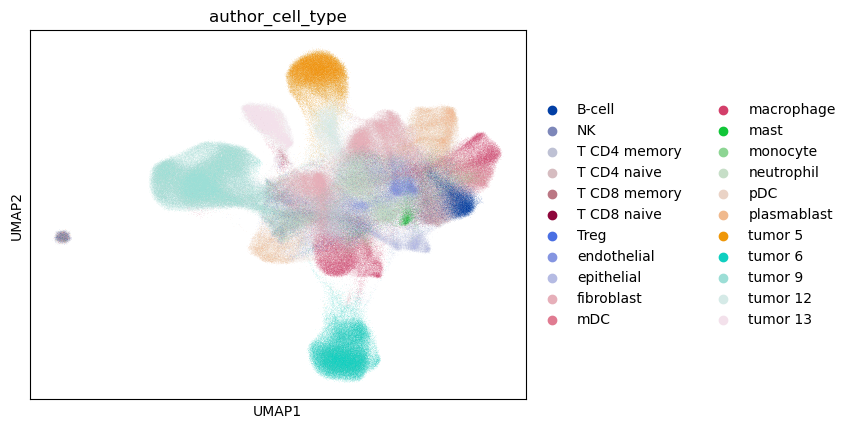

In [ ]:
sc.pl.umap(adata, color = ["author_cell_type"])

## Sliding windows

In [17]:
# check that cells are equally distributed across FOV; prerequisite for sliding window
print(adata.obs.groupby('library_key').size())

library_key
0     98002
1    105800
2     97809
3     89975
4     87606
5    139504
6     71304
7     81236
dtype: int64


/tmp/ipykernel_1599163/765484386.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(adata.obs.groupby('library_key').size())


In [32]:
sliding_window(adata, library_key = 'library_key', window_size=3000, overlap=2500)

Statistics for sliding_window_1:
count     613.000000
mean     1258.133768
std       575.582440
min        28.000000
25%      1000.000000
50%      1329.000000
75%      1645.000000
max      2642.000000
dtype: float64


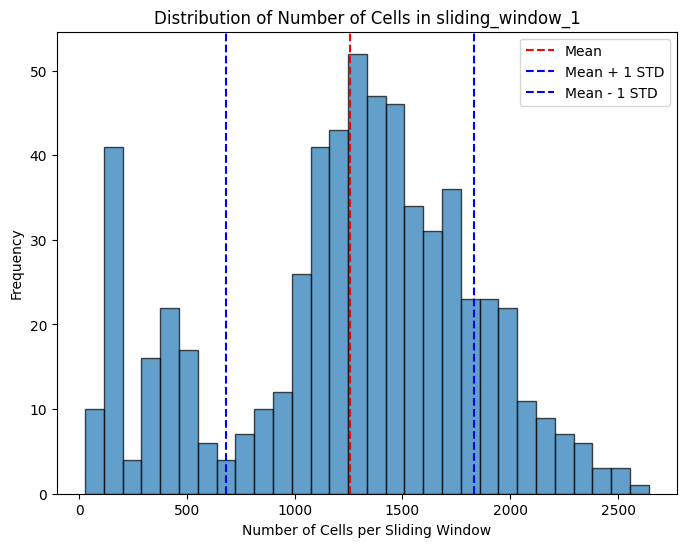

Statistics for sliding_window_2:
count     613.000000
mean     1258.133768
std       527.923131
min        51.000000
25%       953.000000
50%      1318.000000
75%      1616.000000
max      2558.000000
dtype: float64


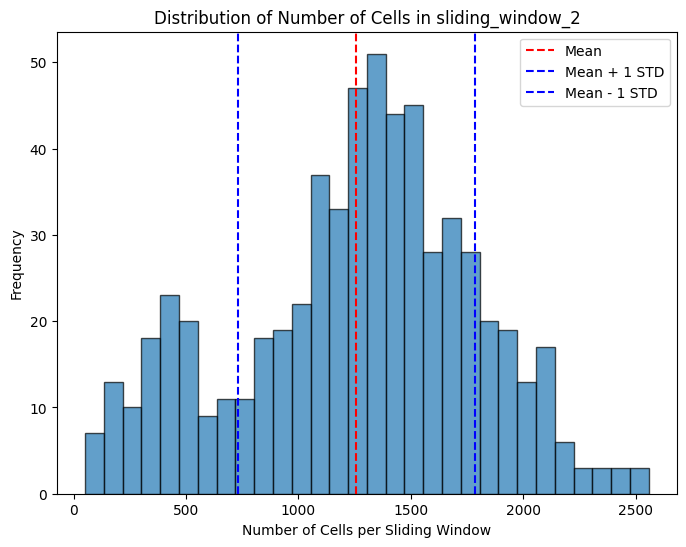

Statistics for sliding_window_3:
count     623.000000
mean     1237.939005
std       550.498087
min        11.000000
25%       937.500000
50%      1280.000000
75%      1615.000000
max      2537.000000
dtype: float64


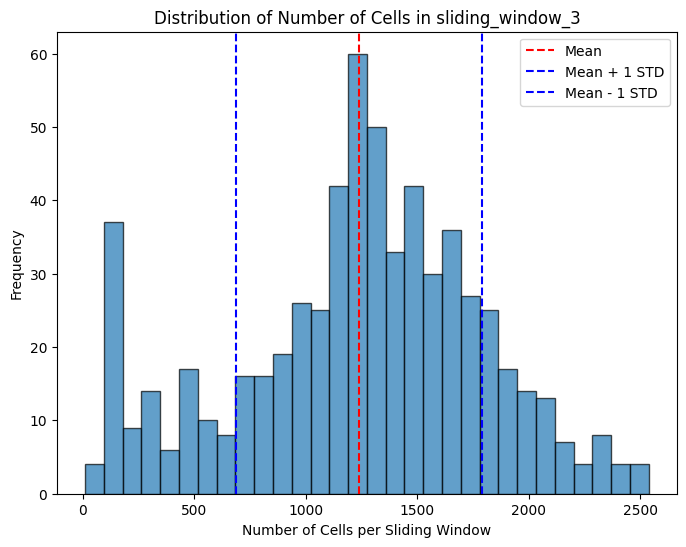

Statistics for sliding_window_4:
count     623.000000
mean     1237.939005
std       502.368262
min        28.000000
25%       913.500000
50%      1269.000000
75%      1590.000000
max      2465.000000
dtype: float64


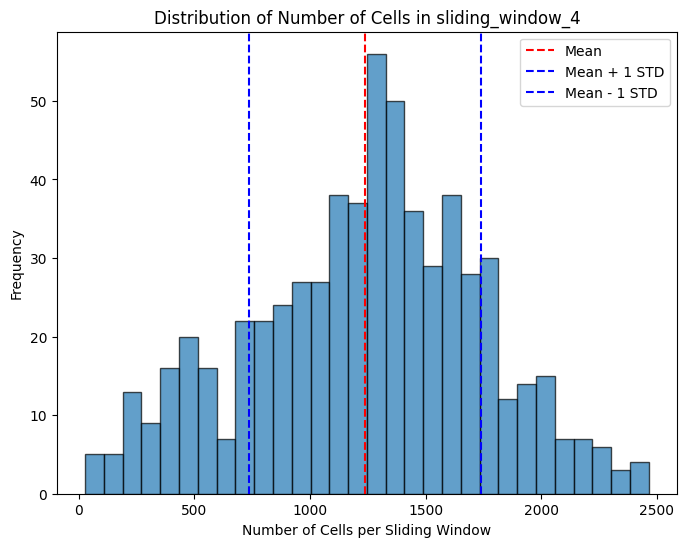

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

total_window_counts = 0

# Iterate through each sliding window ID column
for sliding_window_id in adata.obs.columns[adata.obs.columns.str.contains("sliding_window")]:
    # Calculate the size (number of cells) for each sliding window
    window_sizes = adata.obs.groupby(sliding_window_id).size()
    
    # Display the window sizes
    print(f"Statistics for {sliding_window_id}:")
    print(window_sizes.describe())  # Get a summary of the statistics (min, max, mean, etc.)
    
    # Calculate and print additional statistics
    max_cells = window_sizes.max()
    min_cells = window_sizes.min()
    mean_cells = window_sizes.mean()
    std_cells = window_sizes.std()

    if mean_cells > 2000:
        print(f'Delete {sliding_window_id}')
        del adata.obs[sliding_window_id]
    else:
        total_window_counts += len(window_sizes)
        
        # Plot the distribution of the number of cells
        plt.figure(figsize=(8, 6))
        plt.hist(window_sizes, bins=30, alpha=0.7, edgecolor='black')
        plt.axvline(mean_cells, color='red', linestyle='--', label='Mean')
        plt.axvline(mean_cells + std_cells, color='blue', linestyle='--', label='Mean + 1 STD')
        plt.axvline(mean_cells - std_cells, color='blue', linestyle='--', label='Mean - 1 STD')
        plt.xlabel('Number of Cells per Sliding Window')
        plt.ylabel('Frequency')
        plt.title(f'Distribution of Number of Cells in {sliding_window_id}')
        plt.legend()
        plt.show()

In [20]:
print(f"Nr sliding windows: {len(adata.obs.columns[adata.obs.columns.str.contains('sliding_window')])}")
print(f"Total nr. of windows: {total_window_counts}")

Nr sliding windows: 4
Total nr. of windows: 2472


In [29]:
del adata.obs['nicheformer_split']

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' wi

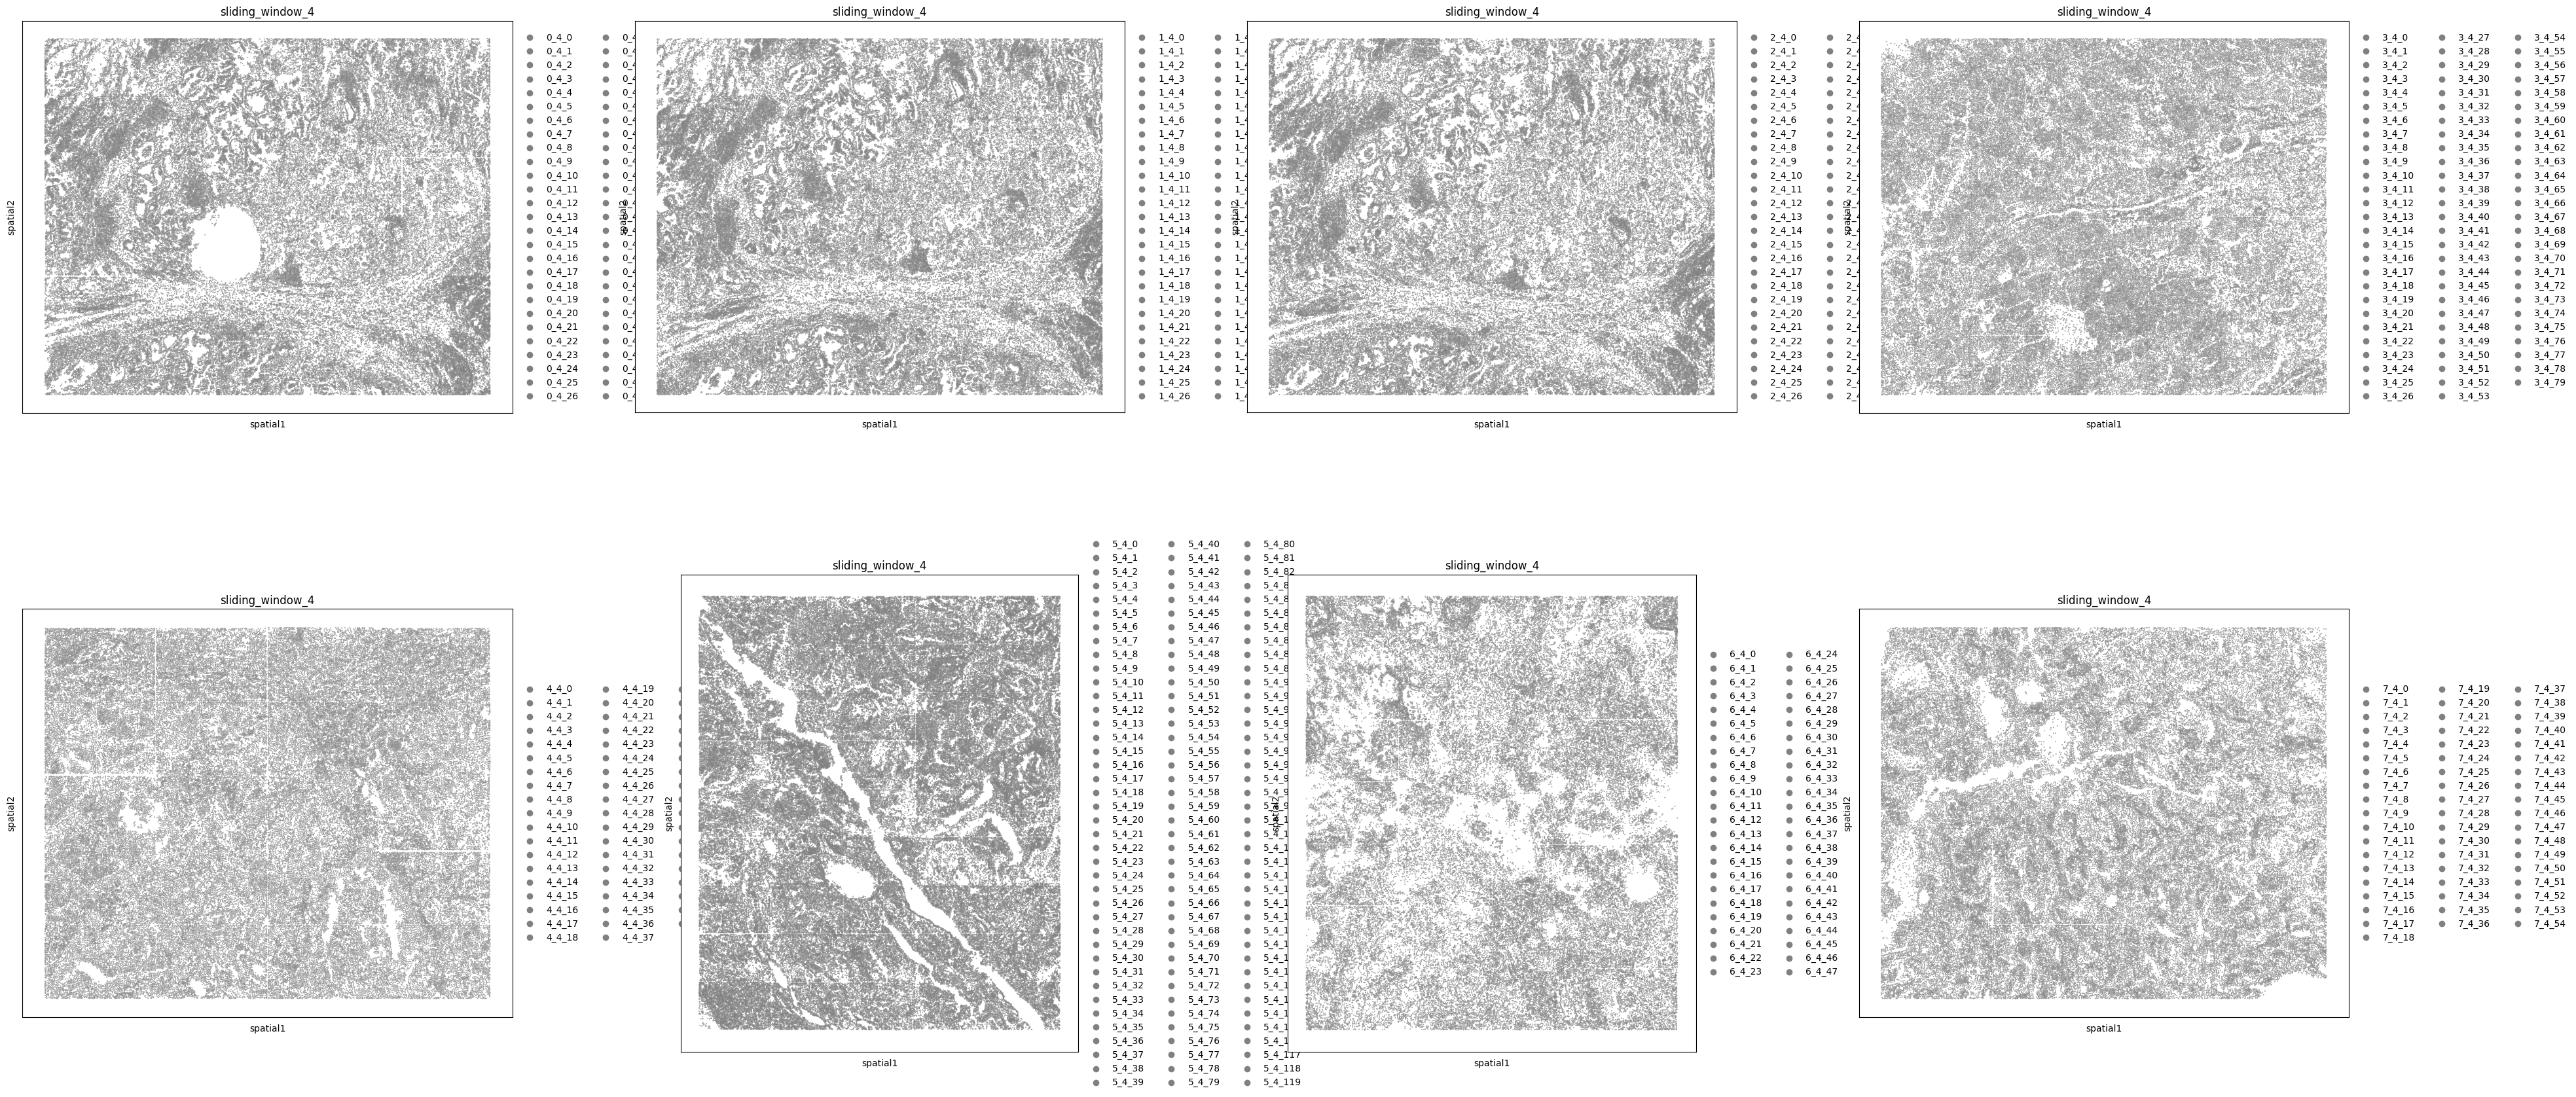

In [27]:
sq.pl.spatial_scatter(
    adata, 
    color="sliding_window_4", 
    library_key="library_key", 
    spatial_key = 'spatial',
    shape=None,
    figsize=(10, 10)
)

In [23]:
adata.write(HE22_HUMAN_LUNG_DATA_PATH)